## ⚙️ Model-Ready Data & Feature Engineering

### 🔹 Purpose of this Notebook

This notebook prepares the dataset for machine learning by applying sampling, feature engineering, and feature selection.

---

### 🔹 Objectives

* Handle class imbalance using sampling
* Preserve data distribution through stratified sampling
* Create meaningful features from existing data
* Remove redundant and highly correlated features
* Prepare final dataset for modeling


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
print('Libraries loaded')

Libraries loaded


In [6]:
df_gold = pd.read_parquet('silver_merged.parquet')
print(f"Silver loaded: {df_gold.shape}")
print(f"Fraud cases: {df_gold['is_fraud'].sum():,}")
print(f"Fraud rate : {df_gold['is_fraud'].mean()*100:.4f}%")

Silver loaded: (8914963, 29)
Fraud cases: 13,332
Fraud rate : 0.1495%


In [7]:
df_gold['year'] = df_gold['date'].dt.year

fraud_df     = df_gold[df_gold['is_fraud'] == 1]
non_fraud_df = df_gold[df_gold['is_fraud'] == 0]

print(f"Fraud cases (keep ALL): {len(fraud_df):,}")
print(f"Non-fraud pool        : {len(non_fraud_df):,}")

Fraud cases (keep ALL): 13,332
Non-fraud pool        : 8,901,631


In [9]:
# ============================================================
# STRATIFIED SAMPLING
# Keep ALL 13,332 fraud + sample 100,000 non-fraud
# Stratify by use_chip + year
# ============================================================

fraud_df     = df_gold[df_gold['is_fraud'] == 1]
non_fraud_df = df_gold[df_gold['is_fraud'] == 0]

print(f"Fraud cases (keep ALL): {len(fraud_df):,}")
print(f"Non-fraud pool        : {len(non_fraud_df):,}")

# Stratified sample by use_chip + year
non_fraud_sample = (
    non_fraud_df
    .groupby(['use_chip', 'year'], group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), max(1, int(100000 * len(x) / len(non_fraud_df)))),
        random_state=42))
)

# Combine fraud + sampled non-fraud
df_sample = pd.concat(
    [fraud_df, non_fraud_sample]).sample(
    frac=1, random_state=42).reset_index(drop=True)

print(f"\n SAMPLING COMPLETE")
print(f"Total rows    : {len(df_sample):,}")
print(f"Fraud cases   : {df_sample['is_fraud'].sum():,}")
print(f"Legit cases   : {(df_sample['is_fraud']==0).sum():,}")
print(f"Fraud rate    : {df_sample['is_fraud'].mean()*100:.2f}%")

print(f"\nuse_chip — full vs sample:")
print(pd.DataFrame({
    'full'  : df_gold['use_chip'].value_counts(
              normalize=True).round(4),
    'sample': df_sample['use_chip'].value_counts(
              normalize=True).round(4)
}))

print(f"\nyear — full vs sample:")
print(pd.DataFrame({
    'full'  : df_gold['year'].value_counts(
              normalize=True).sort_index().round(4),
    'sample': df_sample['year'].value_counts(
              normalize=True).sort_index().round(4)
}))

Fraud cases (keep ALL): 13,332
Non-fraud pool        : 8,901,631

 SAMPLING COMPLETE
Total rows    : 113,320
Fraud cases   : 13,332
Legit cases   : 99,988
Fraud rate    : 11.76%

use_chip — full vs sample:
                      full  sample
Swipe Transaction   0.5236  0.4748
Chip Transaction    0.3593  0.3452
Online Transaction  0.1171  0.1800

year — full vs sample:
        full  sample
2010  0.0933  0.1049
2011  0.0969  0.0859
2012  0.0993  0.0958
2013  0.1018  0.1016
2014  0.1026  0.0965
2015  0.1043  0.1113
2016  0.1046  0.1138
2017  0.1051  0.0944
2018  0.1048  0.1068
2019  0.0872  0.0889


**Interpretation:**

* All fraud cases (13,332) were retained, while non-fraud cases were sampled
* The dataset was reduced to 113,320 rows for efficient processing
* Fraud rate increased from ~0.15% to ~11.76%
* This makes the dataset more suitable for training machine learning models 


In [11]:
df_gold.columns

Index(['id', 'date', 'client_id', 'card_id', 'amount', 'use_chip',
       'merchant_state', 'mcc', 'is_refund', 'is_zero_amount', 'is_fraud',
       'card_brand', 'card_type', 'expires', 'has_chip', 'num_cards_issued',
       'credit_limit', 'acct_open_date', 'year_pin_last_changed',
       'current_age', 'retirement_age', 'gender', 'per_capita_income',
       'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards',
       'mcc_description', 'hour', 'year'],
      dtype='object')

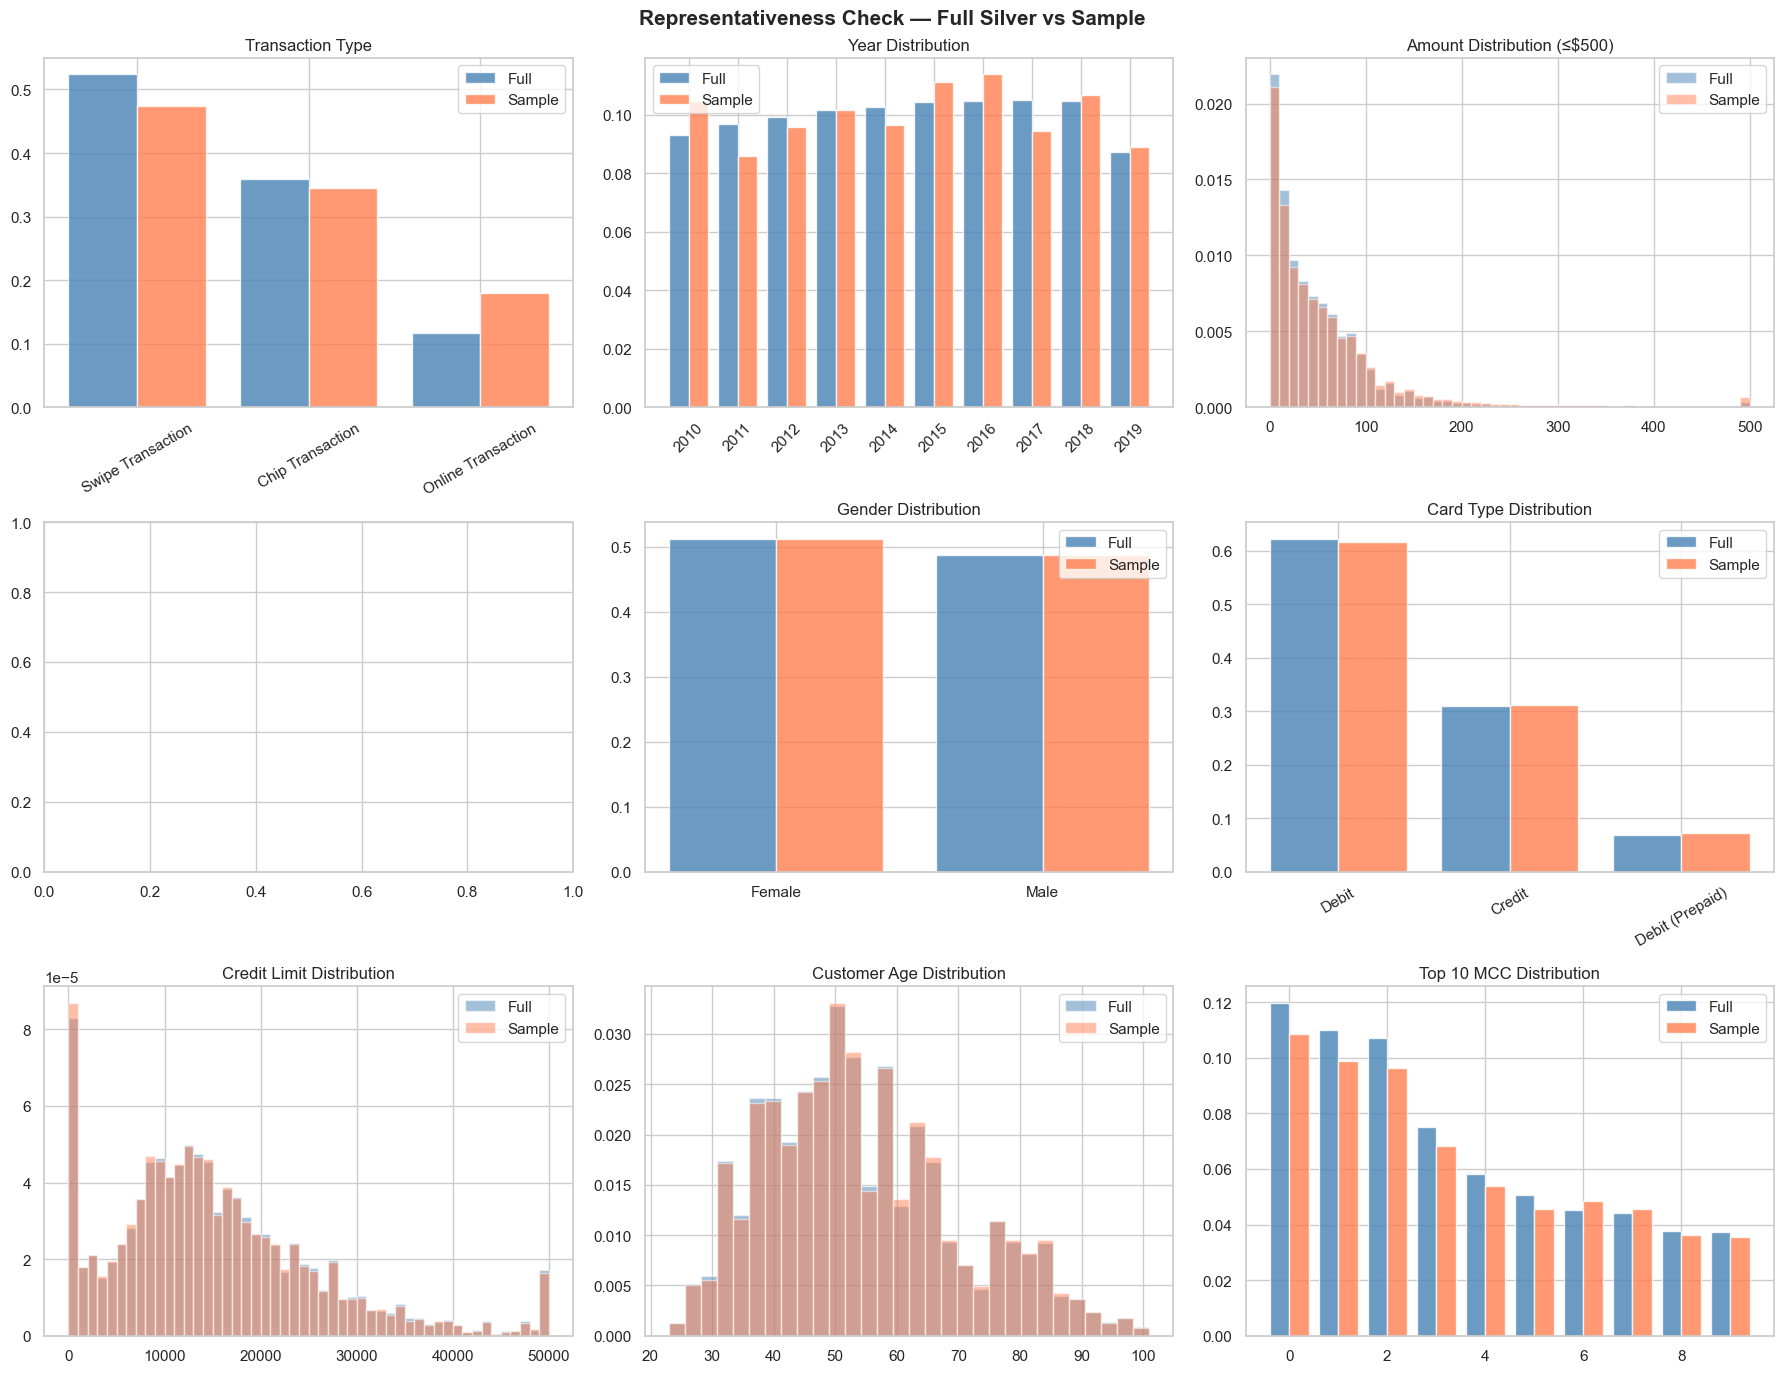


 REPRESENTATIVENESS SUMMARY
Full fraud rate  : 0.1495%
Sample fraud rate: 11.7649%

use_chip proportions:
                      Full  Sample
Swipe Transaction   0.5236  0.4748
Chip Transaction    0.3593  0.3452
Online Transaction  0.1171  0.1800

Year proportions:
        Full  Sample
2010  0.0933  0.1049
2011  0.0969  0.0859
2012  0.0993  0.0958
2013  0.1018  0.1016
2014  0.1026  0.0965
2015  0.1043  0.1113
2016  0.1046  0.1138
2017  0.1051  0.0944
2018  0.1048  0.1068
2019  0.0872  0.0889


In [12]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Representativeness Check — Full Silver vs Sample',
             fontsize=15, fontweight='bold')

# 1. use_chip
full_chip   = df_gold['use_chip'].value_counts(normalize=True)
sample_chip = df_sample['use_chip'].value_counts(normalize=True)
x = range(len(full_chip))
axes[0,0].bar([i-0.2 for i in x], full_chip.values, width=0.4, label='Full', color='steelblue', alpha=0.8)
axes[0,0].bar([i+0.2 for i in x], sample_chip.reindex(full_chip.index).values, width=0.4, label='Sample', color='coral', alpha=0.8)
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(full_chip.index, rotation=30)
axes[0,0].set_title('Transaction Type'); axes[0,0].legend()

# 2. Year
full_year   = df_gold['year'].value_counts(normalize=True).sort_index()
sample_year = df_sample['year'].value_counts(normalize=True).sort_index()
x = range(len(full_year))
axes[0,1].bar([i-0.2 for i in x], full_year.values, width=0.4, label='Full', color='steelblue', alpha=0.8)
axes[0,1].bar([i+0.2 for i in x], sample_year.reindex(full_year.index).fillna(0).values, width=0.4, label='Sample', color='coral', alpha=0.8)
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(full_year.index, rotation=45)
axes[0,1].set_title('Year Distribution'); axes[0,1].legend()

# 3. Amount
axes[0,2].hist(df_gold['amount'].clip(upper=500), bins=50, alpha=0.5, label='Full', color='steelblue', density=True)
axes[0,2].hist(df_sample['amount'].clip(upper=500), bins=50, alpha=0.5, label='Sample', color='coral', density=True)
axes[0,2].set_title('Amount Distribution (≤$500)'); axes[0,2].legend()

# # 4. Errors
# full_err   = df_gold['errors'].value_counts(normalize=True)
# sample_err = df_sample['errors'].value_counts(normalize=True)
# x = range(len(full_err))
# axes[1,0].bar([i-0.2 for i in x], full_err.values, width=0.4, label='Full', color='steelblue', alpha=0.8)
# axes[1,0].bar([i+0.2 for i in x], sample_err.reindex(full_err.index).fillna(0).values, width=0.4, label='Sample', color='coral', alpha=0.8)
# axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(full_err.index, rotation=45)
# axes[1,0].set_title('Error Type Distribution'); axes[1,0].legend()

# 5. Gender
full_gen   = df_gold['gender'].value_counts(normalize=True)
sample_gen = df_sample['gender'].value_counts(normalize=True)
x = range(len(full_gen))
axes[1,1].bar([i-0.2 for i in x], full_gen.values, width=0.4, label='Full', color='steelblue', alpha=0.8)
axes[1,1].bar([i+0.2 for i in x], sample_gen.reindex(full_gen.index).values, width=0.4, label='Sample', color='coral', alpha=0.8)
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(full_gen.index)
axes[1,1].set_title('Gender Distribution'); axes[1,1].legend()

# 6. Card type
full_ct   = df_gold['card_type'].value_counts(normalize=True)
sample_ct = df_sample['card_type'].value_counts(normalize=True)
x = range(len(full_ct))
axes[1,2].bar([i-0.2 for i in x], full_ct.values, width=0.4, label='Full', color='steelblue', alpha=0.8)
axes[1,2].bar([i+0.2 for i in x], sample_ct.reindex(full_ct.index).values, width=0.4, label='Sample', color='coral', alpha=0.8)
axes[1,2].set_xticks(x); axes[1,2].set_xticklabels(full_ct.index, rotation=30)
axes[1,2].set_title('Card Type Distribution'); axes[1,2].legend()

# 7. Credit limit
axes[2,0].hist(df_gold['credit_limit'].clip(upper=50000), bins=50, alpha=0.5, label='Full', color='steelblue', density=True)
axes[2,0].hist(df_sample['credit_limit'].clip(upper=50000), bins=50, alpha=0.5, label='Sample', color='coral', density=True)
axes[2,0].set_title('Credit Limit Distribution'); axes[2,0].legend()

# 8. Age
axes[2,1].hist(df_gold['current_age'], bins=30, alpha=0.5, label='Full', color='steelblue', density=True)
axes[2,1].hist(df_sample['current_age'], bins=30, alpha=0.5, label='Sample', color='coral', density=True)
axes[2,1].set_title('Customer Age Distribution'); axes[2,1].legend()

# 9. MCC
full_mcc   = df_gold['mcc'].value_counts(normalize=True).head(10)
sample_mcc = df_sample['mcc'].value_counts(normalize=True)
x = range(len(full_mcc))
axes[2,2].bar([i-0.2 for i in x], full_mcc.values, width=0.4, label='Full', color='steelblue', alpha=0.8)
axes[2,2].bar([i+0.2 for i in x], sample_mcc.reindex(full_mcc.index).fillna(0).values, width=0.4, label='Sample', color='coral', alpha=0.8)
axes[2,2].set_title('Top 10 MCC Distribution'); axes[2,2].legend()

plt.tight_layout()
plt.savefig('representativeness_check.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n REPRESENTATIVENESS SUMMARY")
print(f"Full fraud rate  : {df_gold['is_fraud'].mean()*100:.4f}%")
print(f"Sample fraud rate: {df_sample['is_fraud'].mean()*100:.4f}%")
print(f"\nuse_chip proportions:")
print(pd.DataFrame({'Full': full_chip.round(4), 'Sample': sample_chip.reindex(full_chip.index).round(4)}))
print(f"\nYear proportions:")
print(pd.DataFrame({'Full': full_year.round(4), 'Sample': sample_year.reindex(full_year.index).fillna(0).round(4)}))

**Interpretation:**

* The sampled dataset closely matches the original dataset across key features
* Distributions of transaction type, year, gender, and card type remain similar
* Minor differences exist but overall structure is preserved
* This confirms that sampling did not distort the data distribution 


## 🏗️ Feature Engineering 

**Features created:**
- Date: year, month, hour, day_of_week, is_night
- Card age: days_until_expiry, account_age_days, years_since_pin_change, is_expired_card
- Ratios: amount_to_limit_ratio, amount_to_income_ratio, debt_to_income_ratio
- Flags: is_high_amount (threshold from training data only)
- Demographics: age_group
- Geographic: merchant_state simplified (rare states → Other)

**Columns dropped:**
- ID columns (id, client_id, card_id) — leakage risk
- Raw date columns replaced by features
- per_capita_income — 0.947 correlation with yearly_income
- retirement_age — correlated with current_age
- mcc_description — redundant with mcc numeric
- is_weekend — 0.789 correlation with day_of_week

In [13]:
df_gold = df_sample.copy()
print(f"Input shape: {df_gold.shape}")

# 1. Date features
df_gold['year']        = df_gold['date'].dt.year
df_gold['month']       = df_gold['date'].dt.month
df_gold['hour']        = df_gold['date'].dt.hour
df_gold['day_of_week'] = df_gold['date'].dt.dayofweek
df_gold['is_night']    = ((df_gold['hour'] >= 22) | (df_gold['hour'] <= 5)).astype(int)

# 2. Card age features
df_gold['days_until_expiry']      = (df_gold['expires'] - df_gold['date']).dt.days
df_gold['account_age_days']       = (df_gold['date'] - df_gold['acct_open_date']).dt.days
df_gold['years_since_pin_change'] = (df_gold['year'] - df_gold['year_pin_last_changed'])
df_gold['is_expired_card']        = (df_gold['days_until_expiry'] < 0).astype(int)
df_gold['account_age_days']       = df_gold['account_age_days'].clip(lower=0)
df_gold['years_since_pin_change'] = df_gold['years_since_pin_change'].clip(lower=0)

# 3. Ratio features
df_gold['amount_to_limit_ratio']  = (df_gold['amount'] / df_gold['credit_limit'].replace(0,1)).clip(0,10)
df_gold['amount_to_income_ratio'] = (df_gold['amount'] / df_gold['yearly_income'].replace(0,1)).clip(0,10)
df_gold['debt_to_income_ratio']   = (df_gold['total_debt'] / df_gold['yearly_income'].replace(0,1))

# 4. Age group for bias analysis
df_gold['age_group'] = pd.cut(
    df_gold['current_age'],
    bins=[0, 25, 35, 50, 65, 100],
    labels=['18-25', '26-35', '36-50', '51-65', '65+']).astype(str)




Input shape: (113320, 30)


In [14]:
drop_cols = [
    'id',
    'client_id',
    'card_id',
    'expires',
    'acct_open_date',
    'year_pin_last_changed',
    'retirement_age',
    'per_capita_income'
]

df_gold = df_gold.drop(columns=drop_cols, errors='ignore')

print(len(df_gold.columns))

33


In [17]:
df_gold['date'] = pd.to_datetime(df_gold['date'], errors='coerce')

df_gold = df_gold.sort_values(by='date')

print("Sorted by date")

Sorted by date


In [18]:
df_gold['month'] = df_gold['date'].dt.month
df_gold['day'] = df_gold['date'].dt.day

**Interpretation:**

* Time-based features (year, month, hour, day_of_week) capture transaction patterns
* Card-related features (account age, expiry status) provide behavioral insights
* Ratio features (amount to income, credit limit, debt) represent financial risk
* Age groups were created for better segmentation and bias analysis
* These features enhance the model’s ability to detect fraud patterns 


Correlation with is_fraud (top 15):
is_fraud                  1.000000
amount                    0.250584
amount_to_limit_ratio     0.104034
num_credit_cards          0.055756
current_age               0.036818
day_of_week               0.033372
amount_to_income_ratio    0.031283
month                     0.015336
has_chip                  0.010207
credit_score              0.006721
is_expired_card           0.004818
day                       0.003602
year                      0.003380
num_cards_issued         -0.000010
years_since_pin_change   -0.001799
Name: is_fraud, dtype: float64

High correlation pairs (>0.7):
  total_debt                     vs debt_to_income_ratio           = 0.7849
  year                           vs days_until_expiry              = -0.7299


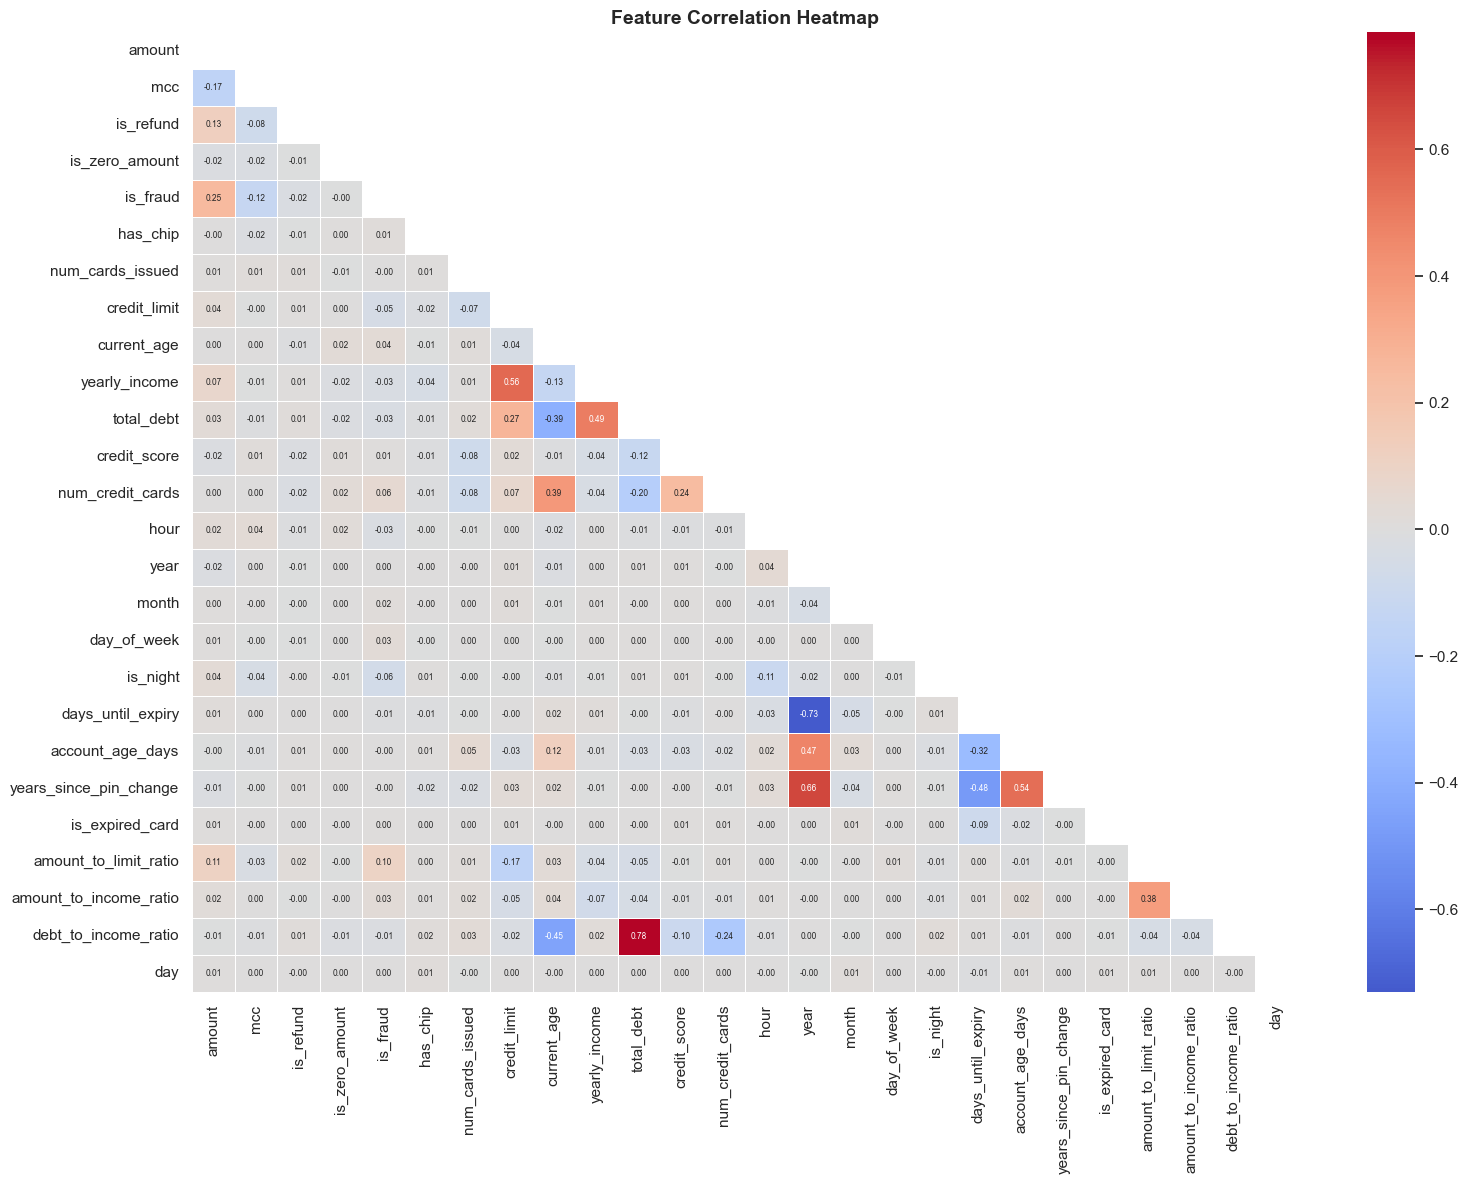

In [20]:
# Numeric correlations with is_fraud
numeric_cols = df_gold.select_dtypes(include=[np.number]).columns.tolist()
corr = df_gold[numeric_cols].corr()

print("Correlation with is_fraud (top 15):")
print(corr['is_fraud'].sort_values(ascending=False).head(15))

# High correlation pairs (potential redundancy)
print("\nHigh correlation pairs (>0.7):")
found = False
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) > 0.7:
            print(f"  {corr.columns[i]:30s} vs {corr.columns[j]:30s} = {corr.iloc[i,j]:.4f}")
            found = True
if not found:
    print("  None found — no multicollinearity issues")

# Heatmap
plt.figure(figsize=(16, 12))
import seaborn as sns
mask = np.triu(np.ones_like(corr, dtype=bool))
exclude = ['id','client_id','card_id']
cols_to_plot = [c for c in numeric_cols if c not in exclude]
corr_plot = df_gold[cols_to_plot].corr()
mask2 = np.triu(np.ones_like(corr_plot, dtype=bool))
sns.heatmap(corr_plot, mask=mask2, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, annot_kws={'size': 6}, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**

* Transaction amount shows the strongest relationship with fraud (~0.25)
* Ratio features such as amount_to_limit_ratio also contribute to prediction
* Most features have low correlation, indicating no strong linear dependence
* Some highly correlated pairs were identified and handled to avoid redundancy 


In [23]:
drop_cols = [
    'total_debt',
    'days_until_expiry'
]
df_gold = df_gold.drop(columns=drop_cols, errors='ignore')


In [25]:
df_gold = df_gold.drop(columns=['mcc'], errors='ignore')

In [26]:
df_gold.columns

Index(['date', 'amount', 'use_chip', 'merchant_state', 'is_refund',
       'is_zero_amount', 'is_fraud', 'card_brand', 'card_type', 'has_chip',
       'num_cards_issued', 'credit_limit', 'current_age', 'gender',
       'yearly_income', 'credit_score', 'num_credit_cards', 'mcc_description',
       'hour', 'year', 'month', 'day_of_week', 'is_night', 'account_age_days',
       'years_since_pin_change', 'is_expired_card', 'amount_to_limit_ratio',
       'amount_to_income_ratio', 'debt_to_income_ratio', 'age_group', 'day'],
      dtype='object')

**Interpretation:**

* ID columns were removed to prevent data leakage
* Highly correlated features such as total_debt and days_until_expiry were removed
* Redundant and less informative features were dropped
* The final feature set is optimized for modeling


In [ ]:
# Saved this model ready files for modelling, and to use for powerbi
df_gold.to_parquet('gold.parquet', index=False)
df_gold.to_csv('gold.csv', index=False)

## 🔹 Key Insights from Feature Engineering

* Class imbalance was handled effectively using stratified sampling

* The sampled dataset maintains similar distributions to the original dataset

* Feature engineering introduced time-based, behavioral, and financial features

* Transaction amount is the most influential feature for fraud detection

* Ratio-based features improve representation of financial risk

* The final dataset is clean, balanced, and ready for machine learning
